# Train and evaluate robot policies on AWS

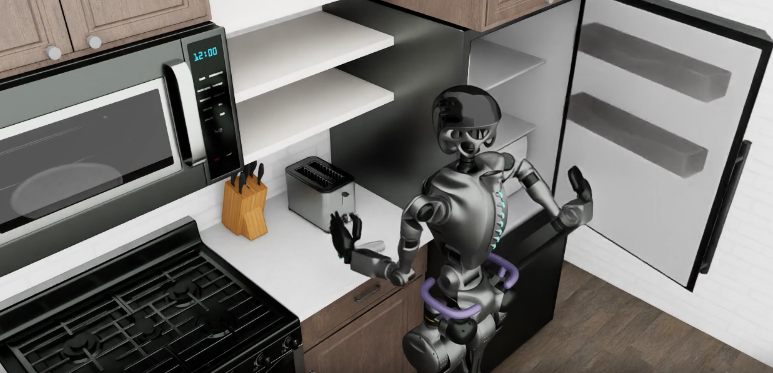

*A simulated humanoid in an Isaac Lab Arena kitchen environment, used to evaluate robot
manipulation policies.*

Prepare the images and infrastructure, fine-tune a policy, evaluate it in simulation, inspect
the results, and remove the resources you created.

The default is **GR00T N1.6 with Isaac Lab Arena**. Other supported selections are GR00T N1.7
with Arena (managed only), GR00T N1.7 with LIBERO, MolmoAct2 with LIBERO, and OpenVLA with LIBERO.

| Execution | Where training and evaluation run | When to use it |
| --- | --- | --- |
| **GPU EC2 instance** (`--mode local`) | Containers on the GPU EC2 instance prepared by this workflow | Debugging and inspecting an experiment on a host you control |
| **SageMaker managed jobs** (`--mode managed`) | GPU instances allocated by SageMaker | Longer experiments with managed compute; capacity waiting can add time |

The notebook issues commands from your computer or notebook instance. **The robot-policy
training and evaluation run in AWS in both cases.** In the CLI, `local` means running containers
on the prepared EC2 host.

Both use `pai arena run`. Add `--sample` for a short, real training/evaluation workload; remove it
and supply explicit budgets for a longer run. An explicit checkpoint argument skips fine-tuning.

The cells below execute the normal command-line workflow. Saved cell outputs show what ran;
a source notebook with empty outputs is not an execution record.


## 1. Edit `config.json` at the repository root

Open [**`config.json` — at the repository root**](../../config.json) and update its
**`arena` section**. This is the existing toolchain configuration file.

Path from the repository root: **`config.json`**. From this notebook directory,
it is **`../../config.json`**. The first code cell prints the full absolute path
for your clone.

| Required setting | What you must provide |
| --- | --- |
| `arena.account_id` | Your twelve-digit AWS workload account ID |
| `arena.hf_token_file` | Absolute path to a file containing your Hugging Face token |
| `arena.ngc_token_file` | Absolute path to a file containing your NVIDIA NGC token |

**Create both token files on the machine running this notebook**, outside the repository.
Each file contains its token as plain text; `config.json` contains only the file path. These
settings are file paths, not Secrets Manager ARNs. Filling in a path does not create its file.

Have AWS credentials for the target account configured and authenticated. Set `arena.profile`
to your named AWS profile, or leave it `null` to use your current credentials or instance role.
Entering `arena.account_id` alone does not grant access to that account.

The editable defaults include `arena.region` (`us-east-1`), the deployment name, prepared cells,
EC2 and SageMaker instance types, runtime limit and recording preference.

### What must exist before deployment?

You provide the AWS account and credentials, permissions to create the resources below, sufficient
GPU quotas, and valid HF/NGC tokens with access to the selected models. The workflow does not
request quota increases.

The deployment command creates the Secrets Manager entries from your token files, IAM roles,
networking and storage, container build resources and images, and the requested GPU EC2 instance
**in the configured AWS account and region**. You do not manually invent or enter secret ARNs.
Writing settings into `config.json` does not create any of these AWS resources.

Have **Python 3.11, Git, Git LFS, AWS CLI v2, Terraform 1.9+ and Bash** installed on the machine
running the notebook. The next cell checks these tools, configuration values, token-file
readability and evidence-storage space without printing tokens. Deployment checks the actual AWS identity, token secrets, GPU quota and selected GR00T
model/data access. NGC authentication and other model downloads are checked by their build
and runtime recipes. AWS permissions are enforced by each API call.

Both this notebook and the Arena CLI read this file through `pai.config`. Explicit CLI arguments
override configuration defaults.


In [ ]:
# Locate this clone, print its configuration path, and check client prerequisites without creating AWS resources.
from pathlib import Path
import sys

repo_root = next((p for p in (Path.cwd(), *Path.cwd().parents)
                  if (p / "pai/config.py").is_file() and (p / "isaac-lab-arena-on-aws").is_dir()), None)
if repo_root is None:
    raise RuntimeError("Open this notebook from your complete toolchain clone.")
component = repo_root / "isaac-lab-arena-on-aws"
print(f"Configuration file: {repo_root / 'config.json'}")
sys.path.insert(0, str(component / "notebooks"))
from check_setup import check_setup

arena_config = check_setup(repo_root)


## 2. Install the command-line tools

Create the virtual environment and install both the shared toolchain CLI and the Arena component.
This installs client software; model images are built later in AWS.

In [ ]:
%%bash -e -s "{component}"
# Create the Python 3.11 environment, install pai/Arena, and show the supported commands and cells.
cd "$1"
python3.11 -m venv .venv
source .venv/bin/activate
python -m pip install -e .. -e .
pai arena --help
pai arena cells --details

In [ ]:
# Use the shared file's settings; generate fresh run IDs to keep each result tied to this notebook session.
import os
from datetime import datetime, timezone
from uuid import uuid4
from pai.config import CONFIG_PATH, load

arena_config = load()["arena"]
os.chdir(component)
os.environ["PATH"] = str(component / ".venv/bin") + os.pathsep + os.environ["PATH"]
if arena_config["profile"]:
    os.environ["AWS_PROFILE"] = arena_config["profile"]
deployment_name = arena_config["deployment_name"]
local_cell = arena_config["local"]["cell"]
managed_cell = arena_config["managed"]["cell"]
local_instance_type = arena_config["local"]["instance_type"]
train_instance_type = arena_config["managed"]["train_instance_type"]
eval_instance_type = arena_config["managed"]["eval_instance_type"]
max_runtime_seconds = arena_config["run"]["max_runtime_seconds"]
session_id = datetime.now(timezone.utc).strftime("%Y%m%d-%H%M%S") + "-" + uuid4().hex[:6]
local_run_id, managed_run_id = "local-" + session_id, "managed-" + session_id
local_report_dir = component / "local-dev/runbook" / local_run_id
managed_report_dir = component / "local-dev/runbook" / managed_run_id
print(f"Configuration: {CONFIG_PATH}")
print(f"Configured AWS target: {arena_config['account_id']} / {arena_config['region']}")
print(f"Train/evaluate on GPU EC2: {local_cell} on {local_instance_type}; run {local_run_id}")
print(f"Managed: {managed_cell}; training {train_instance_type}, evaluation {eval_instance_type}; run {managed_run_id}")
print(f"GPU-job deadline: {max_runtime_seconds} seconds; recording setting: {arena_config['run']['record_video']}")

## 3. Create the AWS resources, build the images and prepare the GPU EC2 instance

`pai arena deploy` reads the `arena` settings from the root `config.json`. Its responsibilities
in the configured AWS account and region are:

| Deployment phase | What it creates or prepares |
| --- | --- |
| Infrastructure and access | Networking, storage, IAM roles and Secrets Manager entries populated from your token files |
| Container images | Build resources and published images for the selected cells |
| GPU EC2 instance | The requested GPU instance, its execution software, selected images and access to the deployment |

This step prepares the environment; training and evaluation start in the later run cells.
No additional CPU test controller is required.

The default `prepare_cells` list includes all five supported selections. Shared images are built
once: GR00T, MolmoAct2, OpenVLA, Arena base and Arena connector. Reduce that list to build fewer
images. For SageMaker-only use, omit `--create-local-host` and skip the GPU EC2 experiment.

**Allow hours for cold setup.** A previous N1.6/Arena-only setup took 2h11m; preparing all families
adds builds and downloads and has not yet been timed. The command waits for preparation to finish
and should identify the current phase, build and instance.


In [ ]:
%%bash -s "{local_instance_type}"
# Read the shared configuration, build the selected images, and create/prepare this GPU EC2 host.
pai arena deploy --create-local-host "$1" --yes

## 4. Confirm what was created

The deployment report checks the expected account and selected image digests. For the GPU EC2
host it reads the running/SSM state, GPU, checkout, downloaded images and both disk reserves.

In [ ]:
%%bash -s "{deployment_name}"
# Show the deployment's actual resources and readiness checks before launching model work.
pai arena status "$1"

## 5. Train and evaluate on the GPU EC2 instance

This command runs containers on the **GPU EC2 instance created in step 3**. The notebook sends
the request and displays progress; it does not train the policy on the machine running Jupyter.
The CLI selects this execution path with `--mode local`.

The sample requests **200 optimizer steps** and **three trials**: three episodes for Arena,
or 30 episodes across LIBERO's ten spatial tasks. Its threshold is zero to check the workflow;
the actual robot success count remains a separate result.

Change `arena.local.cell` in the root `config.json` to select another cell for the GPU EC2 instance.
N1.7/Arena is managed-only. The previous N1.6/Arena sample took about 27 minutes after preparation;
other cells may take longer. Recording adds rendering work, so that timing is not a video-run
guarantee.


In [ ]:
%%bash -s "{local_cell}" "{local_run_id}" "{max_runtime_seconds}"
# Fine-tune and evaluate this cell on the prepared EC2 host; Arena recording follows the shared config.
pai arena run --cell "$1" --mode local --sample \
  --run-id "$2" --max-runtime-seconds "$3" --wait

### What happened on the GPU EC2 instance?

Export the evidence for the **exact run ID**, then show a plain-English summary, task counts and
its own recorded video. The report separates requested and observed training steps, demonstrations
available in the dataset, evaluation episodes, robot successes, elapsed time and verification.
Unknown values are shown as not reported; training steps are never called training episodes.

In [ ]:
%%bash -s "{local_run_id}" "{local_report_dir}"
# Export this run's existing evidence and any recorded video; do not submit or repeat an experiment.
pai arena report "$1" --output-dir "$2" --include-video

In [ ]:
# Explain the completed GPU EC2 run and display only the video exported for that run.
from display_results import show_run_results
show_run_results(local_report_dir, expected_run_id=local_run_id)

## 6. Train and evaluate the selected cell in SageMaker

SageMaker allocates the explicitly selected GPU instances for FineTune and SimEval. The full
managed sequence continues through Validate, SuccessGate and RegisterModel. These jobs do not
run on the notebook or on the GPU EC2 instance created in step 3. Capacity waiting can add to the runtime.

Change `arena.managed.cell` and the two managed instance choices in the shared configuration for
another cell. The sample still performs real training. A successful workflow does not mean a
high-quality policy, and registration does not automatically approve the model for use.

In [ ]:
%%bash -s "{managed_cell}" "{managed_run_id}" "{train_instance_type}" "{eval_instance_type}" "{max_runtime_seconds}"
# Fine-tune/evaluate this cell in SageMaker, then wait through validation and model registration.
pai arena run --cell "$1" --mode managed --sample \
  --instance FineTune="$3" --instance SimEval="$4" \
  --run-id "$2" --max-runtime-seconds "$5" --wait

### What happened in that managed run?

The summary describes the actual experiment and its registration result. With Arena recording
enabled, it also shows footage from that managed run. Unsupported simulators show an explanation
instead of a video. Only recordings belonging to this execution are shown.

In [ ]:
%%bash -s "{managed_run_id}" "{managed_report_dir}"
# Export the exact managed execution's evidence and recording, including its registration result.
pai arena report "$1" --output-dir "$2" --include-video

In [ ]:
# Summarize the actual managed result and display its own verified downloaded video, if supported.
show_run_results(managed_report_dir, expected_run_id=managed_run_id)

## 7. Optional: longer training or checkpoint reuse

The same cell selections and commands apply. For a longer run, remove `--sample` and supply the
training steps, evaluation trials and threshold you want. These example budgets are illustrative,
not a claim that a particular number of steps produces a useful policy.

The commands below are commented out so Run All only launches the two selected samples. Uncomment
the experiment you want. No launch switches or private scripts change the meaning of these commands.

In [ ]:
%%bash -s "{local_cell}"
# Optional longer experiment on the GPU EC2 instance: choose your own budgets and uncomment to launch.
# pai arena run --cell "$1" --mode local \
#   --train-steps 10000 --eval-trials 20 --threshold 0.5 \
#   --max-runtime-seconds 86400 --wait

In [ ]:
%%bash -s "{managed_cell}" "{train_instance_type}" "{eval_instance_type}"
# Optional longer managed experiment: choose budgets/hardware and uncomment to launch.
# pai arena run --cell "$1" --mode managed \
#   --train-steps 10000 --eval-trials 20 --threshold 0.5 \
#   --instance FineTune="$2" --instance SimEval="$3" \
#   --max-runtime-seconds 86400 --wait

In [ ]:
%%bash -s "{managed_cell}" "{eval_instance_type}" "{max_runtime_seconds}"
# Optional: supply a compatible exact checkpoint object in a versioned bucket; this explicitly skips FineTune.
# pai arena run --cell "$1" --mode managed --sample \
#   --checkpoint-s3 s3://YOUR_BUCKET/YOUR_CHECKPOINT_OBJECT \
#   --instance SimEval="$2" --max-runtime-seconds "$3" --wait

## 8. Preserve the results and remove the resources

Teardown must include every GPU EC2 or SageMaker run created under this deployment, including
additional runs from the optional examples. It preserves verified results on the notebook's machine, removes the
owned AWS resources and temporary archive, and checks that deletion actually finished. Shared or
supplied resources keep their original owner. Allow time for large checkpoint/evidence transfers.

The report directories and embedded notebook videos remain readable after AWS teardown. No new
experiment runs in this step.

In [ ]:
%%bash -s "{deployment_name}"
# Archive verified evidence locally, remove this deployment's owned AWS resources, and verify deletion.
pai arena destroy "$1" --remove-evidence --yes

In [ ]:
%%bash -s "{deployment_name}"
# Show the final removal checks and retained local evidence location for this deployment.
pai arena status "$1"

## Keep the execution record

This notebook runs in place. Jupyter saves its outputs normally. For unattended execution from
an activated environment, the optional terminal executor saves the same file every five seconds,
at cell boundaries and on errors:

```bash
python -m pip install -e '.[notebook]'
python notebooks/execute_runbook.py
```

Run those commands from `isaac-lab-arena-on-aws`. The executor does not change the cell commands
or configuration. It retains a copy of previous outputs under `local-dev/notebook-executions/`
before a new Run All. A failure stops later cells and remains visible; inspect the error and use
the CLI's recorded operation to resume it rather than launching duplicate work.

The results helper only presents exported evidence. A completed execution record
shows the account, source revision and resources used; it applies to that execution
and does not certify another account or a later code revision.
